<a href="https://colab.research.google.com/github/kethelineberlin/Intelig-ncia-Computacional-Aplicada-Gera-o-de-Energia-e-Sustentabilidade/blob/main/kethetline_XAI_MHP_25042026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Ketheline**, em todo trabalho científico voce precisa de um objetivo, gerado a partir de um problema. Então, por favor, responda:
1.   Qual o contexto e problema?
2.   Qual o objetivo?
3.   Para que fazer esse estudo?
4.   Qual a contribuição com os resultados do estudo?

(precisa iniciar respondendo essas questões, ok?)

# Descrição da Análise (proposta)

Bolsista: **Ketheline Berlin**

**Projeto**: Avaliação de Algoritmos de Aprendizado Profundo Aplicados à Predição da Geração de Energia Solar Fotovoltaica

**Artigo**: Análise Exploratória de Dados e  Inteligência Artificial Explicável: Análise de Variáveis do Método Híbrido de Predição da Geração Fotovoltaica

**Objetivo**: Aplicar a Análise Exploratória de Dados (EDA) e métodos de Inteligência Artificial Explicável (XAI) para identificar as variáveis de entrada mais relevantes à Predição da Irradiância Solar do Método Híbrido de Predição (MHP) da Geração Fotovoltaica

**Método**:
1. Realizar o Pré-processamento do dataset.
2. Fazer a Análise Exploratória de Dados (EDA) no dataset.
3. Aplicar métodos de Inteligência Artificial Explicável (XAI): Feature Importance + SHAP na Rede Neural Artificial do MHP.
4. Sintetizar e descrever resultados.

**Resultado**: Identificar, analisar e descrever quais as variáveis (inputs) são mais relevantes para a predição da irradiância solar realizada pelo Método Híbrido de Predição (MHP)?

**Contribuição**: Identificar as variáveis mais relevantes permite otimizar os algoritmos de predição e aumentar a acurácia do MHP, que contribui para a segurança e estabilidade da rede elétrica que vem sendo afetada pela intermitência de geração da energia fotovoltaica.

# Pré-processamento + EDA

**Prompt 1:**
Analise o código atual selecionado. Altere-o e converta a coluna timestamp para data e hora para facilitar a plotagem das séries temporais (outras colunas). Mantenha somente cloudsMovement de 1, 5, e 15 minutos, removendo as demais colunas cloudsMovement. Revise a análise EDA e gráficos. Apresente as estatísticas descritivas basicas de cada variável e correlação com a folsomGhi, que é a variável alvo a ser predita. Não gere mais relatórios em arquivo e nem dados processados. Apresente a EDA em tela direto no notebook.

**Prompt 2:**
Altere o código atual e incremente um gráfico que plota todas as variáveis para um conjunto de 5 dias seguidos, na mesma figura, com um gráfico em cada linha. O último deve ser a variável folsomGhi (alvo).

Baixando e carregando dados...
✅ Dataset processado: 764867 linhas e 13 colunas.

Estatisticas Descritivas Basicas:


,timeStamp,cloudsCoverage,clearSkyGhi,sunLuminance,fitLuminanceCSI,sunLocated,cloudsSunAround,whitePixelRatio,folsomGhi,cloudsMovement1,cloudsMovement5,cloudsMovement15
count,764867,764867.000000,764867.000000,764867.000000,764867.000000,764867.000000,764867.000000,764867.000000,764867.000000,764867.000000,764867.000000,764867.000000
mean,2015-07-10 18:54:40.580937472,0.263340,450.514444,48875.731471,24635.825753,0.915729,0.498752,0.074911,412.818832,73.614801,224.956472,391.577028
min,2014-01-02 15:28:00,0.000000,0.041900,323.022400,0.058400,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2014-10-06 22:53:30,0.007600,204.662500,44441.593300,9466.420100,1.000000,0.001000,0.040500,142.300000,7.905600,25.562250,61.047950
50%,2015-07-07 23:16:00,0.182600,448.429400,53506.666800,24280.682300,1.000000,0.467800,0.070700,381.500000,18.483300,61.842100,139.004900
75%,2016-04-16 19:04:30,0.543600,691.246700,56671.501100,39204.048350,1.000000,0.999700,0.109600,658.300000,67.807850,252.302000,482.858150
max,2016-12-31 00:47:00,0.900000,950.203400,64029.057700,61697.647500,1.000000,1.000000,0.337400,1466.000000,2959.920000,7835.957700,9580.634500
std,NaN,0.269332,284.266396,11350.029586,16754.885356,0.277794,0.489397,0.050315,295.528791,145.957688,383.482338,574.834402



Correlacao com a variavel alvo (folsomGhi):


,folsomGhi
folsomGhi,1.000000
fitLuminanceCSI,0.943714
clearSkyGhi,0.889618
sunLuminance,0.596023
sunLocated,0.336855
whitePixelRatio,0.040571
cloudsMovement1,-0.135480
cloudsMovement5,-0.177982
cloudsMovement15,-0.203298
cloudsSunAround,-0.327134



Visualizacoes da EDA:


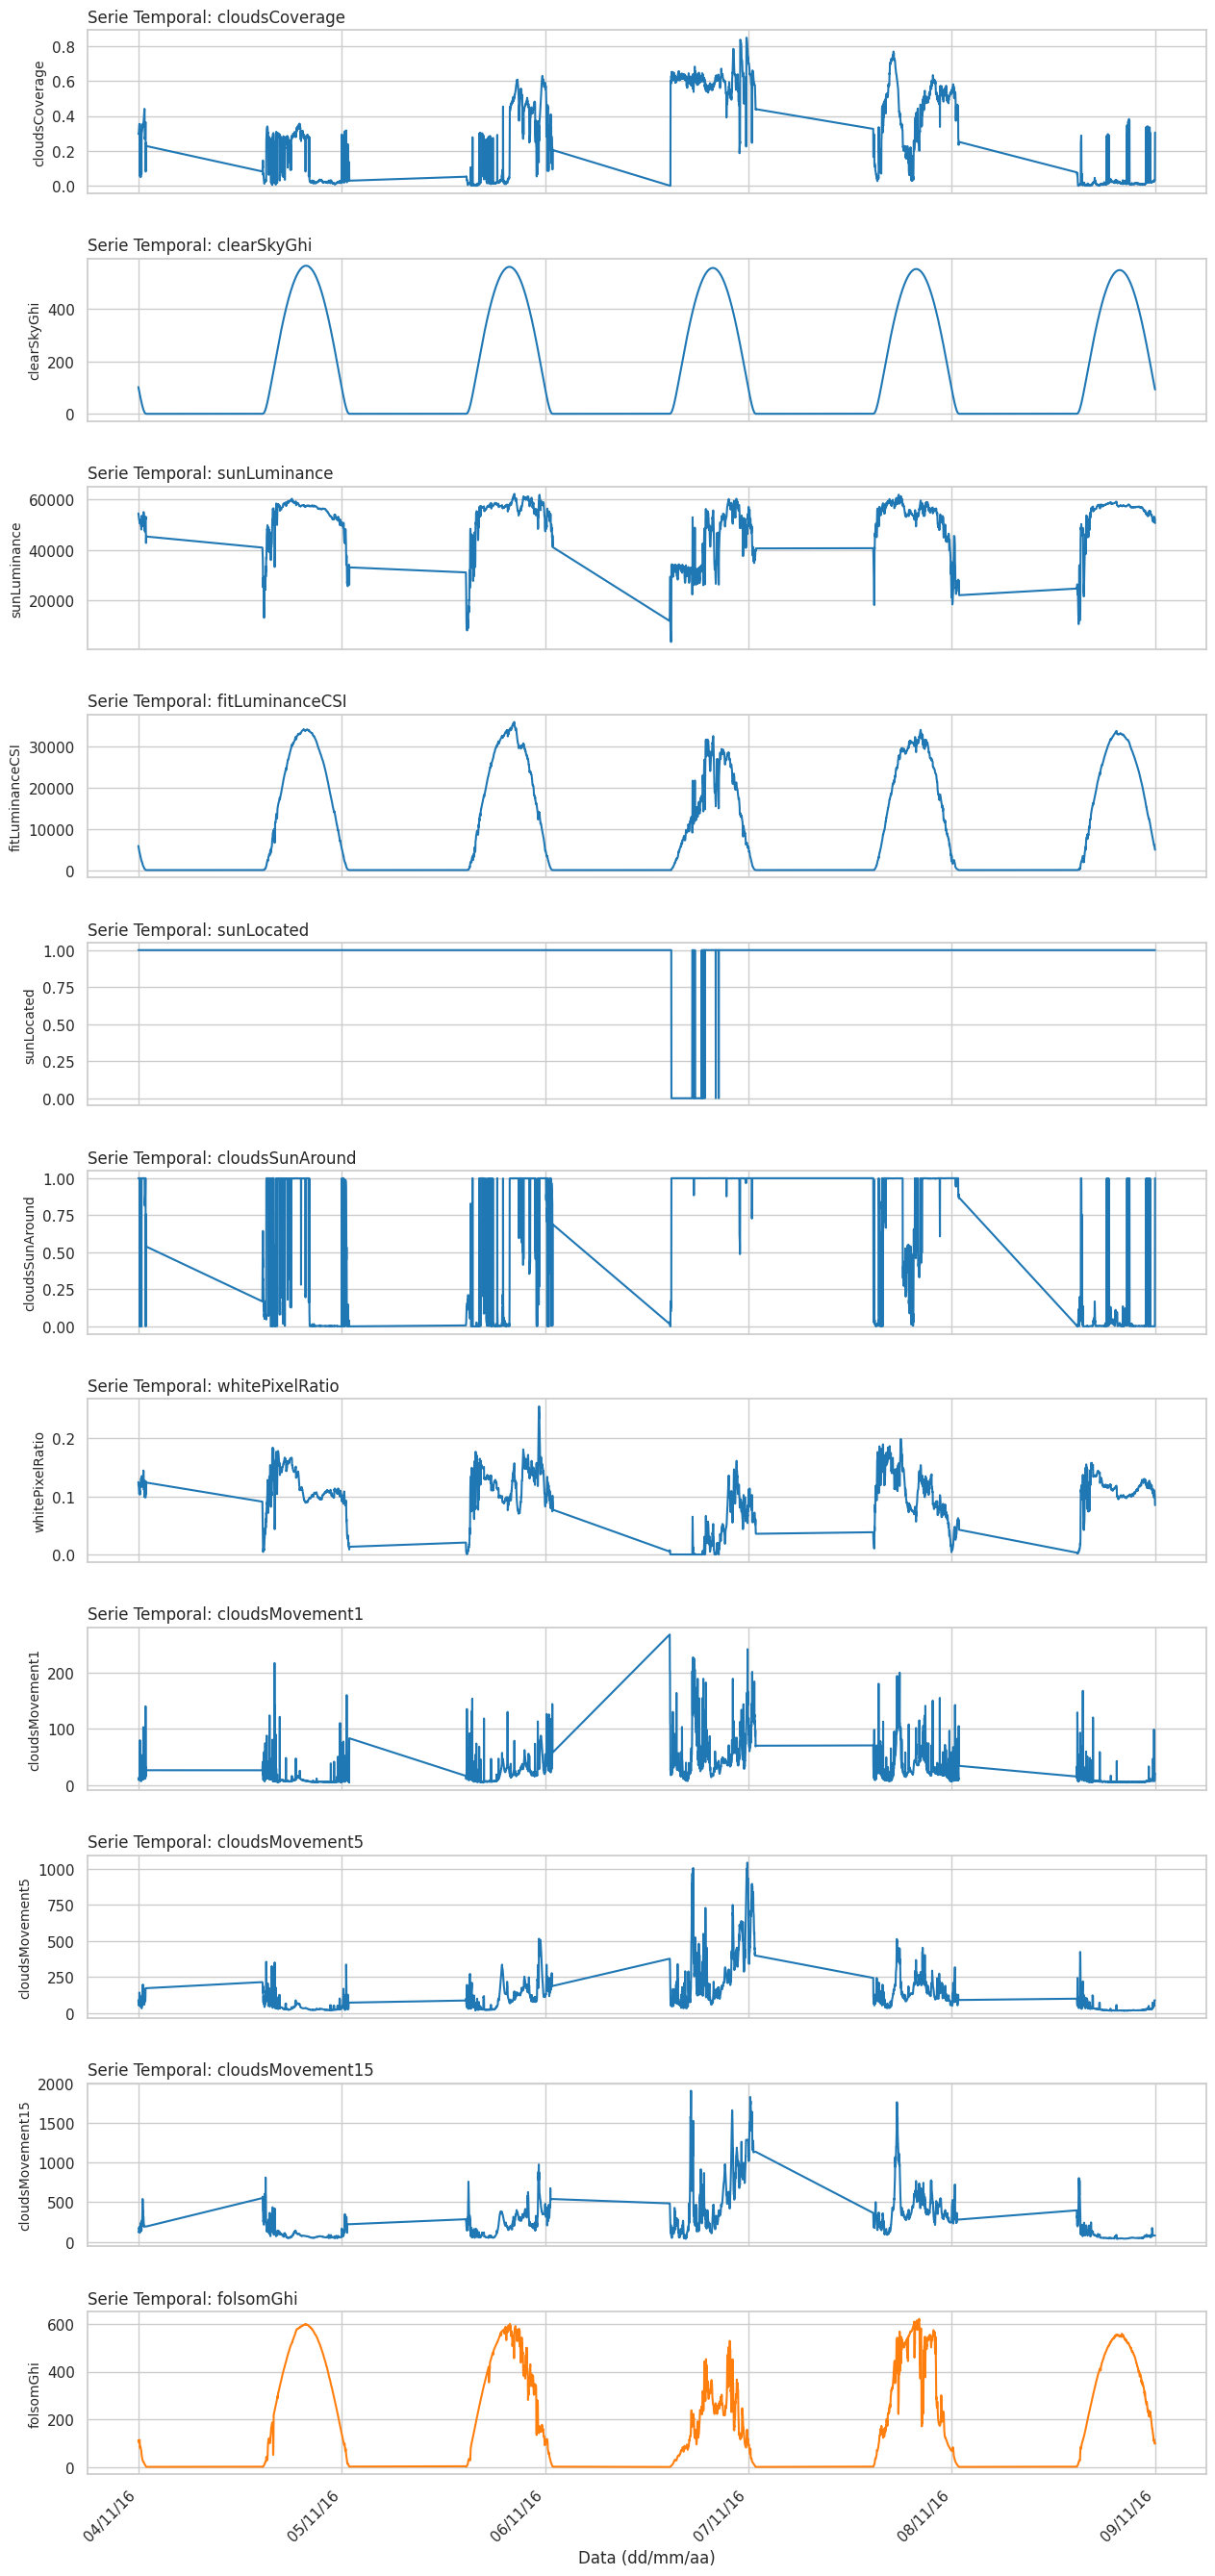

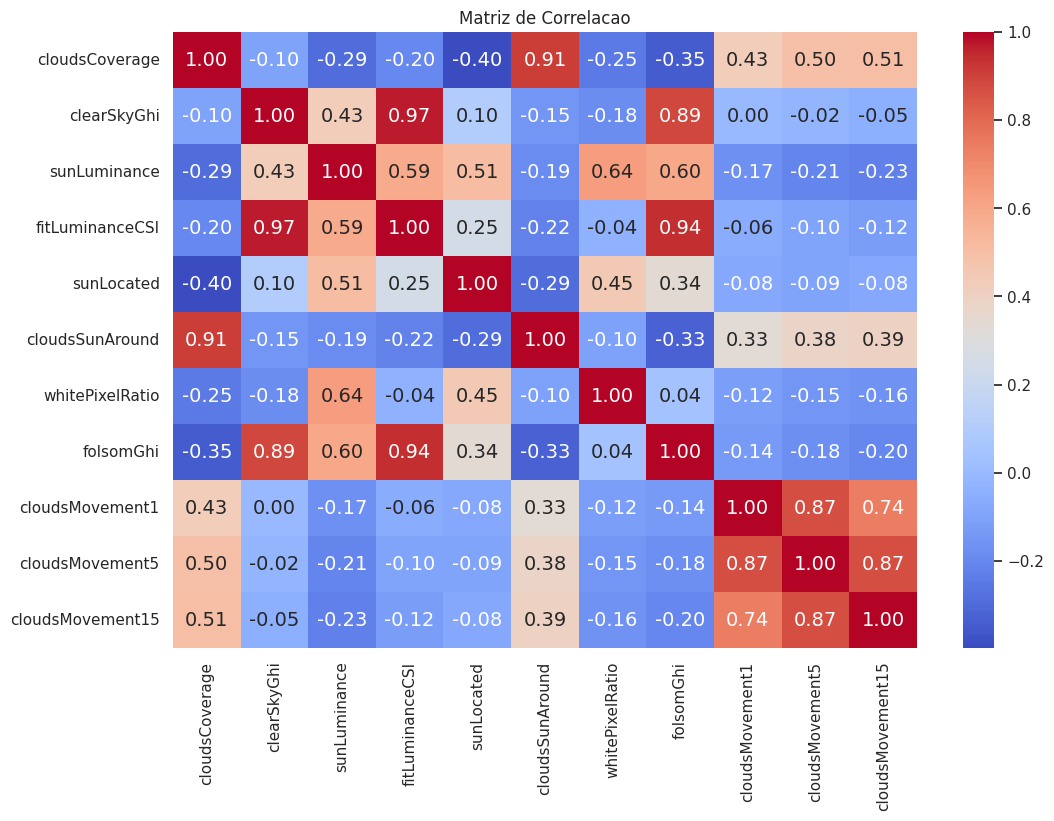

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import requests
import zipfile
import os
import io
import warnings
from datetime import datetime, timedelta

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

# Definir tamanho de fonte global para os gráficos
plt.rcParams.update({'font.size': 14})

# 1. DOWNLOAD E CARREGAMENTO
URL_DATASET = 'https://data.mendeley.com/public-files/datasets/347p98c2rd/files/02a9d960-e4ed-4d9e-b9bf-d9f372e84b78/file_downloaded'
temp_zip = '/tmp/dataset.zip'

print('Baixando e carregando dados...')
response = requests.get(URL_DATASET, stream=True)
with open(temp_zip, 'wb') as f:
    f.write(response.content)

with zipfile.ZipFile(temp_zip, 'r') as zip_ref:
    zip_ref.extractall('/tmp/')

df = pd.read_csv('/tmp/features_image_mhp.csv', sep=';', decimal=',')

# 2. PRE-PROCESSAMENTO
df['timeStamp'] = pd.to_datetime(df['timeStamp'])

# Filtrar colunas cloudsMovement
cols_to_keep = [col for col in df.columns if not col.startswith('cloudsMovement')] + ['cloudsMovement1', 'cloudsMovement5', 'cloudsMovement15']
df = df[cols_to_keep]

print(f'✅ Dataset processado: {df.shape[0]} linhas e {df.shape[1]} colunas.')

# 3. EDA - ESTATISTICAS E CORRELACAO
print('\nEstatisticas Descritivas Basicas:')
display(df.describe())

print('\nCorrelacao com a variavel alvo (folsomGhi):')
correlations = df.select_dtypes(include=[np.number]).corr()['folsomGhi'].sort_values(ascending=False)
display(correlations.to_frame())

# 4. VISUALIZACOES
print('\nVisualizacoes da EDA:')

# --- CONFIGURAÇÃO DA JANELA DE PLOT ---
data_inicio_plot = '2016-11-04'

start_date = pd.to_datetime(data_inicio_plot)
end_date = start_date + timedelta(days=5)
df_5days = df[(df['timeStamp'] >= start_date) & (df['timeStamp'] < end_date)]

if df_5days.empty:
    print(f'⚠️ Aviso: Nenhum dado encontrado para a data {data_inicio_plot}. Verifique o intervalo do dataset.')
else:
    vars_to_plot = [col for col in df.columns if col not in ['folsomGhi', 'timeStamp', 'season']]
    vars_to_plot.append('folsomGhi')

    fig, axes = plt.subplots(nrows=len(vars_to_plot), ncols=1, figsize=(15, 3 * len(vars_to_plot)), sharex=True)
    plt.subplots_adjust(hspace=0.4)

    for i, var in enumerate(vars_to_plot):
        axes[i].plot(df_5days['timeStamp'], df_5days[var], color='tab:blue' if var != 'folsomGhi' else 'tab:orange')
        axes[i].set_ylabel(var, fontsize=10)
        axes[i].set_title(f'Serie Temporal: {var}', loc='left')

        # Formatação do Eixo X
        axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%d/%m/%y'))
        plt.setp(axes[i].get_xticklabels(), rotation=45, ha='right')

    axes[-1].set_xlabel('Data (dd/mm/aa)')
    plt.show()

# Heatmap de Correlacao
plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Matriz de Correlacao')
plt.show()

**Prompt 3**:
a partir do dataset carregado, agrupe os dias em três classes a partir da irradiância (folsomGhi): céu claro, nublado e extremamente nublado ou chuvoso. Depois plote um gráfico de boxplot para cada variável com boxplots agruando os dias em cada uma das três classes.

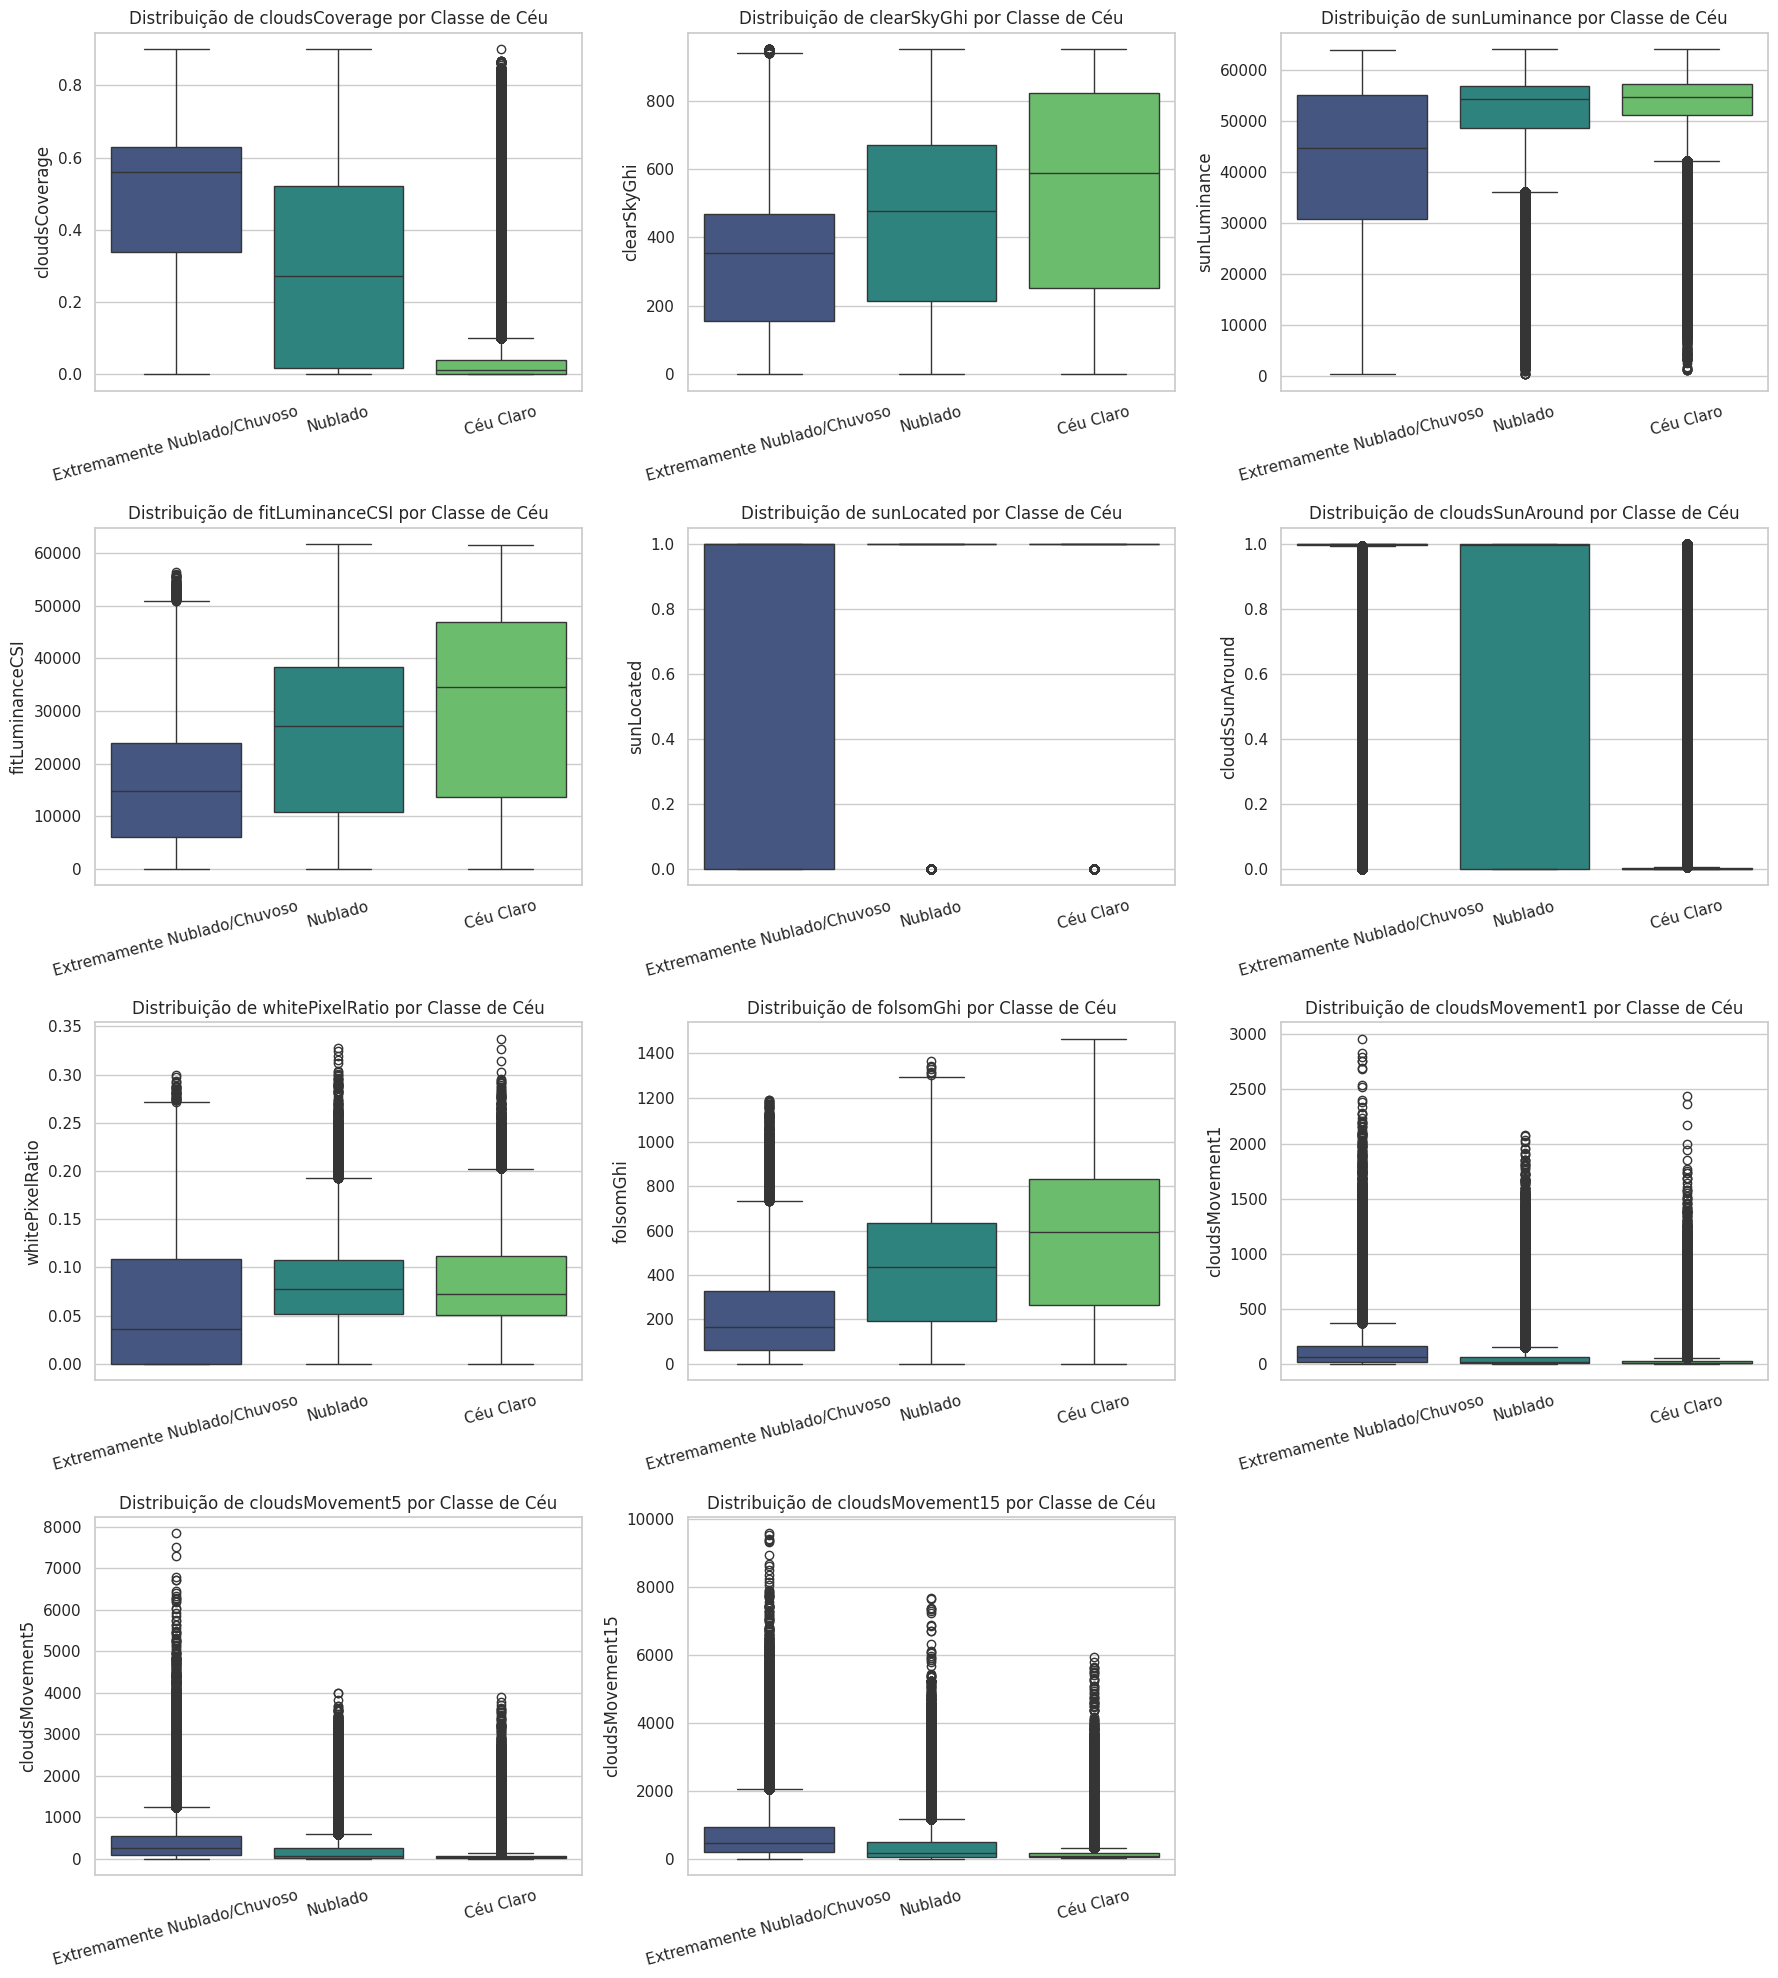

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Agrupar por dia para calcular a irradiância média diária
df['date'] = df['timeStamp'].dt.date
daily_ghi = df.groupby('date')['folsomGhi'].mean().reset_index()
daily_ghi.columns = ['date', 'avg_daily_ghi']

# 2. Definir as classes baseadas nos tercis ou limiares de irradiância
# Aqui usamos quantis para garantir uma distribuição equilibrada,
# mas você pode ajustar os valores fixos se preferir.
low_threshold = daily_ghi['avg_daily_ghi'].quantile(0.33)
high_threshold = daily_ghi['avg_daily_ghi'].quantile(0.66)

def classify_sky(ghi):
    if ghi <= low_threshold:
        return 'Extremamente Nublado/Chuvoso'
    elif ghi <= high_threshold:
        return 'Nublado'
    else:
        return 'Céu Claro'

daily_ghi['sky_class'] = daily_ghi['avg_daily_ghi'].apply(classify_sky)

# 3. Mesclar a classificação de volta ao dataframe original
df = df.merge(daily_ghi[['date', 'sky_class']], on='date', how='left')

# 4. Plotar Boxplots para cada variável
vars_to_box = [col for col in df.columns if col not in ['timeStamp', 'season', 'date', 'sky_class']]

# Configurar layout dos subplots
n_cols = 3
n_rows = (len(vars_to_box) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, var in enumerate(vars_to_box):
    sns.boxplot(x='sky_class', y=var, data=df, ax=axes[i], palette='viridis',
                order=['Extremamente Nublado/Chuvoso', 'Nublado', 'Céu Claro'])
    axes[i].set_title(f'Distribuição de {var} por Classe de Céu')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=15)

# Remover eixos vazios
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# XAI




## Feature Importance

**Ketheline, leia esse prompt**:
Utilizando o dataset anterior, carregue-o novamamente. Crie a coluna inicial de timestamp convertida para data e hora. Elabore uma Análise Exploratória de Dados das variáveis existentes. A variável folsomGhi é alvo, a ser predita. Elabore uma análise de importância das variáveis (explicabilidade) para modelo de Rede Neural Artifical. Crie um relatório final com a análise EDA e importância das variáveis para predição de folsomGhi.

Entenda-o. Depois conversaremos sobre.

🔄 Recarregando e preparando dados...
📊 Realizando EDA focada no alvo: folsomGhi


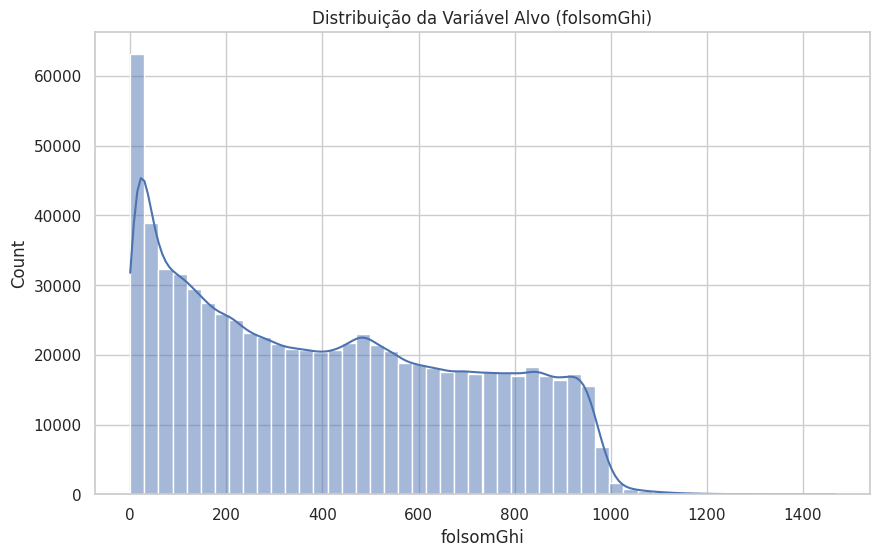


🔗 Principais correlações com folsomGhi:
folsomGhi          1.000000
fitLuminanceCSI    0.943714
clearSkyGhi        0.889618
sunLuminance       0.596023
hour               0.457486
sunLocated         0.336855
Name: folsomGhi, dtype: float64

🧠 Treinando Rede Neural para análise de importância...
🧪 Calculando Permutation Importance (Explicabilidade)...


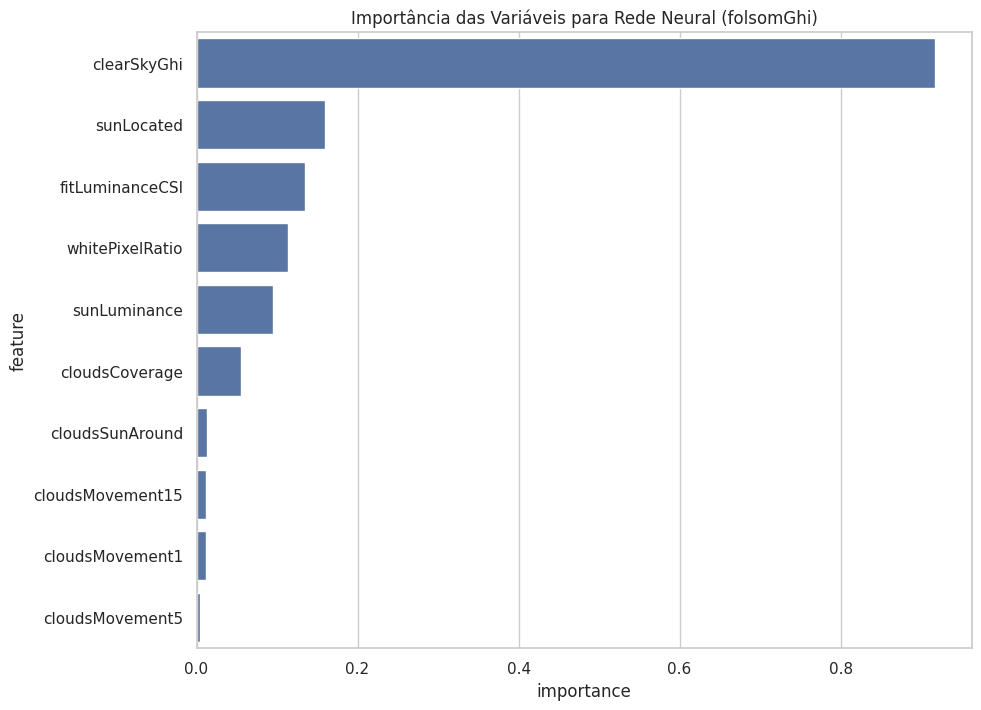


📝 RELATÓRIO DE PREDIÇÃO: folsomGhi
1. ALVO: folsomGhi (Irradiância Solar)
2. MELHORES PREDICTORES (Correlação): fitLuminanceCSI e clearSkyGhi
3. EXPLICABILIDADE RNA: A variável mais importante para o modelo foi 'clearSkyGhi'.
4. INSIGHT: Variáveis de movimento de nuvens e métricas de claridade de céu dominam a capacidade preditiva.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.inspection import permutation_importance
import os

# 1. Carregamento e Conversão
print("🔄 Recarregando e preparando dados...")
# Usando a variável df já carregada no estado do notebook para otimizar,
# mas garantindo a conversão do timestamp conforme solicitado.
df['timeStamp'] = pd.to_datetime(df['timeStamp'])
df['hour'] = df['timeStamp'].dt.hour
df['month'] = df['timeStamp'].dt.month

# 2. EDA focada em folsomGhi
print("📊 Realizando EDA focada no alvo: folsomGhi")
plt.figure(figsize=(10, 6))
sns.histplot(df['folsomGhi'], bins=50, kde=True)
plt.title('Distribuição da Variável Alvo (folsomGhi)')
plt.show()

# Correlação com o alvo
corr_target = df.select_dtypes(include=[np.number]).corr()['folsomGhi'].sort_values(ascending=False)
print("\n🔗 Principais correlações com folsomGhi:")
print(corr_target.head(6))

# 3. Preparação para Rede Neural (Explicabilidade)
print("\n🧠 Treinando Rede Neural para análise de importância...")
# Selecionando features (removendo o alvo e colunas não numéricas/originais de tempo)
# Adicionando 'date' e 'sky_class' para exclusão, pois são colunas não numéricas adicionadas anteriormente.
features = [col for col in df.columns if col not in ['folsomGhi', 'timeStamp', 'season', 'date', 'sky_class', 'hour', 'month']]
X = df[features].dropna()
# Garantir que X contenha apenas tipos de dados numéricos
X = X.select_dtypes(include=[np.number])
y = df.loc[X.index, 'folsomGhi']

# Amostragem para agilizar a explicabilidade (Permutation Importance é custoso)
X_sample, _, y_sample, _ = train_test_split(X, y, train_size=10000, random_state=42)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_sample)

mlp = MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
mlp.fit(X_scaled, y_sample)

# 4. Importância das Variáveis (Permutation Importance)
print("🧪 Calculando Permutation Importance (Explicabilidade)...")
result = permutation_importance(mlp, X_scaled, y_sample, n_repeats=5, random_state=42)

importance_df = pd.DataFrame({
    'feature': features,
    'importance': result.importances_mean
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', data=importance_df)
plt.title('Importância das Variáveis para Rede Neural (folsomGhi)')
plt.show()

# 5. Relatório Final
print("\n" + "="*50)
print("📝 RELATÓRIO DE PREDIÇÃO: folsomGhi")
print("="*50)
print(f"1. ALVO: folsomGhi (Irradiância Solar)")
print(f"2. MELHORES PREDICTORES (Correlação): {corr_target.index[1]} e {corr_target.index[2]}")
print(f"3. EXPLICABILIDADE RNA: A variável mais importante para o modelo foi '{importance_df.iloc[0]['feature']}'.")
print(f"4. INSIGHT: Variáveis de movimento de nuvens e métricas de claridade de céu dominam a capacidade preditiva.")
print("="*50)

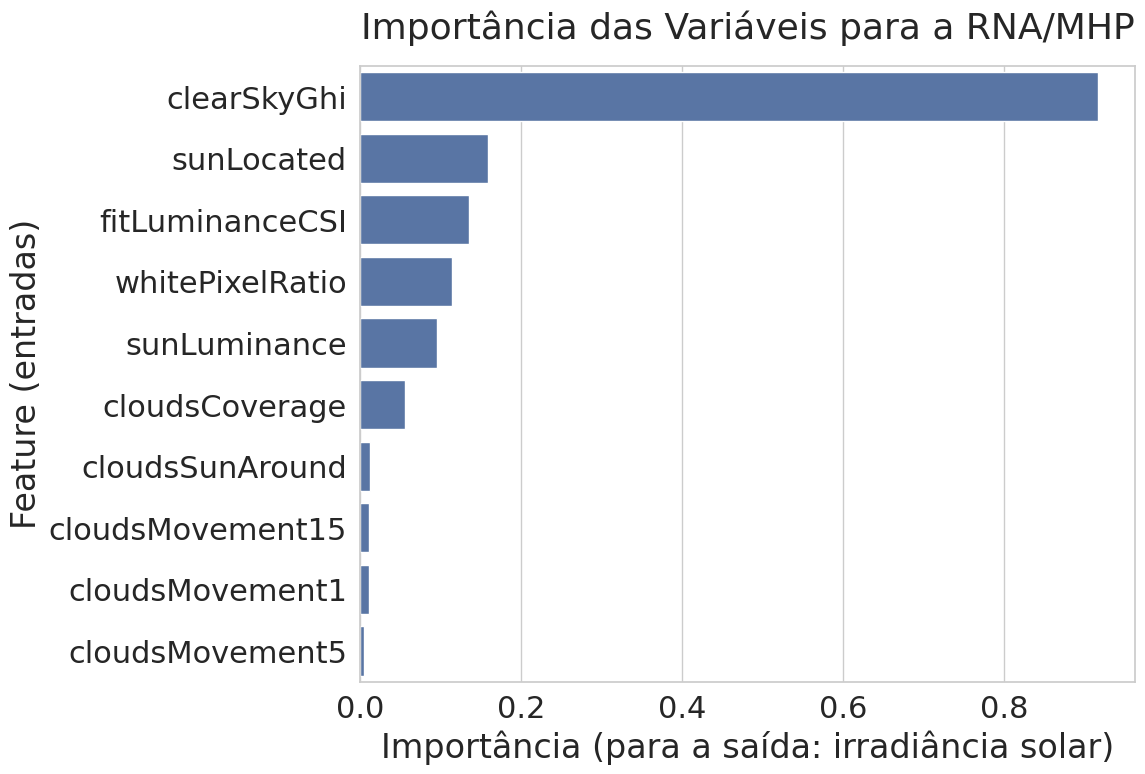


📝 RELATÓRIO DE PREDIÇÃO: Irradiância Solar
1. ALVO: folsomGhi (Irradiância Solar)
2. MELHORES PREDICTORES (Correlação): fitLuminanceCSI e clearSkyGhi
3. EXPLICABILIDADE RNA: A variável mais importante para o modelo foi 'clearSkyGhi'.
4. INSIGHT: Variáveis de movimento de nuvens e métricas de claridade de céu dominam a capacidade preditiva.


In [ ]:
plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', data=importance_df)
plt.title('Importância das Variáveis para a RNA/MHP', fontsize=26, pad=20)
plt.title('Importância das Variáveis para a RNA/MHP', fontsize=26, pad=20)
plt.xlabel('Importância (para a saída: irradiância solar)', fontsize=24)
plt.ylabel('Feature (entradas)', fontsize=24)
plt.xticks(fontsize=22)
plt.yticks(fontsize=22)
plt.show()

# 5. Relatório Final
print("\n" + "="*50)
print("📝 RELATÓRIO DE PREDIÇÃO: Irradiância Solar")
print("="*50)
print(f"1. ALVO: folsomGhi (Irradiância Solar)")
print(f"2. MELHORES PREDICTORES (Correlação): {corr_target.index[1]} e {corr_target.index[2]}")
print(f"3. EXPLICABILIDADE RNA: A variável mais importante para o modelo foi '{importance_df.iloc[0]['feature']}'.")
print(f"4. INSIGHT: Variáveis de movimento de nuvens e métricas de claridade de céu dominam a capacidade preditiva.")
print("="*50)

## SHAP

**Prompt:** Como a análise de explicabilidade de IA pode ser realizada de forma adicional a anterior usando SHAP?

🧪 Calculando valores SHAP (Explicabilidade Adicional)...


  0%|          | 0/100 [00:00<?, ?it/s]

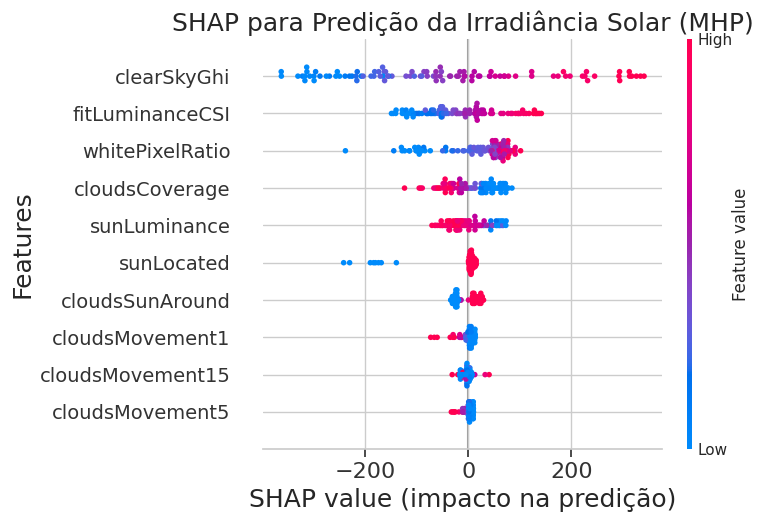


💡 Insight SHAP:
O gráfico acima mostra o impacto (SHAP value) de cada variável. 
Cores vermelhas indicam valores altos da variável, e azuis valores baixos.
Isso nos ajuda a entender a direção do impacto na predição de folsomGhi.


In [ ]:
!pip install shap -q
import shap
import matplotlib.pyplot as plt

print("🧪 Calculando valores SHAP (Explicabilidade Adicional)...")
# O SHAP KernelExplainer funciona bem com qualquer modelo (incluindo MLP)
# Usaremos uma pequena amostra para o 'background' para acelerar o cálculo
X_summary = shap.sample(X_scaled, 50)
explainer = shap.KernelExplainer(mlp.predict, X_summary)

# Calculando valores SHAP para uma amostra de teste
shap_values = explainer.shap_values(X_scaled[:100])

# Gerando o gráfico de resumo (Summary Plot)
# Aumentando o figsize para acomodar fontes maiores
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values, X_sample.iloc[:100], feature_names=features, show=False) # Use show=False para customizar antes de mostrar

# Pega o eixo atual para customização
ax = plt.gca()

# Aumenta o tamanho da fonte para o título
ax.set_title('SHAP para Predição da Irradiância Solar (MHP)', fontsize=18)

# Aumenta o tamanho da fonte para os rótulos dos eixos
ax.set_xlabel('SHAP value (impacto na predição)', fontsize=18)
ax.set_ylabel('Features', fontsize=18)

# Aumenta o tamanho da fonte para os ticks (rótulos dos eixos)
ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=14)

plt.tight_layout() # Ajusta o layout para evitar sobreposição
plt.show() # Mostra o gráfico

print("\n💡 Insight SHAP:")
print("O gráfico acima mostra o impacto (SHAP value) de cada variável. ")
print("Cores vermelhas indicam valores altos da variável, e azuis valores baixos.")
print("Isso nos ajuda a entender a direção do impacto na predição de folsomGhi.")